In [1]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeKyiv
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend = AerSimulator()

# backend=FakeKyiv()
# sampler = Sampler(backend = backend)
pm = generate_preset_pass_manager(backend=backend,optimization_level=2)

In [2]:


nb_qubits = 6

N = 2**nb_qubits
m = np.zeros((N,N))
for j in range(N):
    if j == N-1:
        break
    else:
       m[j,j+1] = -1 

for j in range(N):
    if j == N-1:
        break
    else:
       m[j+1,j] = -1 
for j in range(N):
   m[j,j] = 2 
m[0] = np.array([1]+ [0]*(N-1))
m[1,0] = 0

# b = np.array([0]+[1]*47+[2]*5+[0]*11])

c = 1e-0
v0 = 1
y = 1
b = np.array([0,c,0,0,0,0,0,0,0,0,0,0,0,0,0,c+v0*y]*4)
b=b/np.linalg.norm(b)

In [3]:
np.linalg.det(m)



64.0000000000006

In [4]:
def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))
b

array([-4.85722573e-17+2.08166817e-17j,  2.23606798e-01-2.22044605e-16j,
        1.38777878e-17+4.16333634e-17j, -1.23259516e-32-3.08148791e-33j,
       -1.38777878e-17+3.46944695e-17j,  5.39260384e-33-5.39260384e-33j,
       -1.84889275e-32+3.85185989e-33j,  1.71056941e-48-6.50016377e-48j,
       -5.55111512e-17+6.93889390e-17j,  1.15555797e-32-2.85037632e-32j,
        3.08148791e-32+1.54074396e-32j, -2.73691106e-48-5.47382213e-48j,
       -1.38777878e-17+2.77555756e-17j, -9.24446373e-33-6.16297582e-33j,
       -9.71445147e-17+2.77555756e-17j,  4.47213595e-01+1.11022302e-16j,
       -4.85722573e-17+2.08166817e-17j,  2.23606798e-01-2.22044605e-16j,
        1.38777878e-17+4.16333634e-17j, -1.23259516e-32-3.08148791e-33j,
       -1.38777878e-17+3.46944695e-17j,  5.39260384e-33-5.39260384e-33j,
       -1.84889275e-32+3.85185989e-33j,  1.71056941e-48-6.50016377e-48j,
       -5.55111512e-17+6.93889390e-17j,  1.15555797e-32-2.85037632e-32j,
        3.08148791e-32+1.54074396e-32j, -2.73691106

In [5]:
def Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    def tensor(p,q,i,j,k,l):
        return np.kron(p,np.kron(q,np.kron(i,np.kron(j,np.kron(k,l)))))
    M1 = (np.dot(np.dot(Ub,tensor(z,I,I,I,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,z,I,I,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,z,I,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,I,z,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,I,I,z,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,I,I,I,z)),np.conj(Ub.T)))
    M = 0.5*np.dot(np.dot(np.conj(m.T),(tensor(I,I,I,I,I,I) - M1/nb_qubits)),m)

    return M
A = Hamiltonian(m)

In [6]:
d,u = np.linalg.eig(A)
d

array([1.19438555e+01-7.38613527e-17j, 1.02720576e+01-1.01338444e-16j,
       9.53474181e+00+3.72030325e-17j, 9.41120780e+00-2.64948304e-16j,
       9.41197035e+00-1.80457166e-16j, 7.84502294e+00+1.33030750e-16j,
       7.85230899e+00-1.09515188e-16j, 7.59827678e+00-1.08292917e-16j,
       7.36664009e+00+4.75848205e-17j, 7.32856677e+00+3.04297446e-16j,
       6.66866485e+00-6.71712204e-17j, 6.91869854e+00+3.39364575e-16j,
       5.71307232e+00+1.89922092e-16j, 5.59214491e+00+9.92908828e-17j,
       5.40275653e+00-1.13857358e-16j, 5.49187388e+00-7.49779599e-17j,
       5.15184720e+00-1.64042214e-16j, 4.99510578e+00+2.09111212e-16j,
       4.77978056e+00-1.61647946e-16j, 4.46809557e+00+5.77520109e-17j,
       3.98589495e+00+1.21835475e-16j, 3.64211313e+00-1.54516542e-17j,
       3.47181375e+00+5.04103487e-16j, 3.42929703e+00-1.81471538e-16j,
       3.28207514e+00-5.33866575e-17j, 2.99982107e+00-1.98443495e-16j,
       2.56948109e+00+3.76719087e-17j, 2.40233999e+00-3.15847538e-16j,
      

In [7]:
U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 
U5=scl.expm(2**4*2*np.pi*1j*A) 
U6=scl.expm(2**5*2*np.pi*1j*A) 
U7=scl.expm(2**6*2*np.pi*1j*A) 
U8=scl.expm(2**7*2*np.pi*1j*A)
U9=scl.expm(2**8*2*np.pi*1j*A) 
U10=scl.expm(2**9*2*np.pi*1j*A) 
U11=scl.expm(2**10*2*np.pi*1j*A) 
U12=scl.expm(2**11*2*np.pi*1j*A)
U13=scl.expm(2**12*2*np.pi*1j*A) 
U14=scl.expm(2**13*2*np.pi*1j*A) 
U15=scl.expm(2**14*2*np.pi*1j*A)
U16=scl.expm(2**15*2*np.pi*1j*A) 
 

 
u1gate=UnitaryGate(U1)
u2gate=UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)
u5gate=UnitaryGate(U5)
u6gate=UnitaryGate(U6)
u7gate=UnitaryGate(U7)
u8gate=UnitaryGate(U8)
u9gate=UnitaryGate(U9)
u10gate=UnitaryGate(U10)
u11gate=UnitaryGate(U11)
u12gate=UnitaryGate(U12)
u13gate=UnitaryGate(U13)
u14gate=UnitaryGate(U14)
u15gate=UnitaryGate(U15)
u16gate=UnitaryGate(U16)




In [8]:
Id = np.identity(2**nb_qubits)
z0 = np.array([[1,0],
               [0,0]])
z1 = np.array([[0,0],
               [0,1]])

CU1 = np.kron(Id,z0) + np.kron(U1,z1)
CU2 = np.kron(Id,z0) + np.kron(U2,z1)
CU3 = np.kron(Id,z0) + np.kron(U3,z1)
CU4 = np.kron(Id,z0) + np.kron(U4,z1)
CU5 = np.kron(Id,z0) + np.kron(U5,z1)
CU6 = np.kron(Id,z0) + np.kron(U6,z1)
CU7 = np.kron(Id,z0) + np.kron(U7,z1)
CU8 = np.kron(Id,z0) + np.kron(U8,z1)
CU9 = np.kron(Id,z0) + np.kron(U9,z1)
CU10 = np.kron(Id,z0) + np.kron(U10,z1)
CU11 = np.kron(Id,z0) + np.kron(U11,z1)
CU12 = np.kron(Id,z0) + np.kron(U12,z1)
CU13 = np.kron(Id,z0) + np.kron(U13,z1)
CU14 = np.kron(Id,z0) + np.kron(U14,z1)
CU15 = np.kron(Id,z0) + np.kron(U15,z1)
CU16 = np.kron(Id,z0) + np.kron(U16,z1)



C_u1gate=UnitaryGate(CU1)
C_u2gate=UnitaryGate(CU2)
C_u3gate=UnitaryGate(CU3)
C_u4gate=UnitaryGate(CU4)
C_u5gate=UnitaryGate(CU5)
C_u6gate=UnitaryGate(CU6)
C_u7gate=UnitaryGate(CU7)
C_u8gate=UnitaryGate(CU8)
C_u9gate=UnitaryGate(CU9)
C_u10gate=UnitaryGate(CU10)
C_u11gate=UnitaryGate(CU11)
C_u12gate=UnitaryGate(CU12)
C_u13gate=UnitaryGate(CU13)
C_u14gate=UnitaryGate(CU14)
C_u15gate=UnitaryGate(CU15)
C_u16gate=UnitaryGate(CU16)


[0.05145285 0.16212569 0.49316096 0.4052961  0.12518138 0.94345683
 0.81209812 0.38701357 0.26201778 0.75143449 0.75115973 0.01015426
 0.38699332 0.34243863 0.4277144  0.3302829  0.69296778 0.60371413
 0.6617106  0.93953061 0.80236756 0.9596587  0.88692455 0.08482896
 0.00813994 0.64985383 0.08441884 0.76119411 0.69573319 0.21043226
 0.96708973 0.40972907 0.4435394  0.54674529 0.96556555 0.52278073
 0.11369606 0.40161863 0.44333345 0.80650353 0.29002813 0.28213638
 0.01296697 0.32039161 0.2795081  0.70526085 0.2716424  0.89501745
 0.63808767 0.21899544 0.52000262 0.97949799 0.40966426 0.29172039]


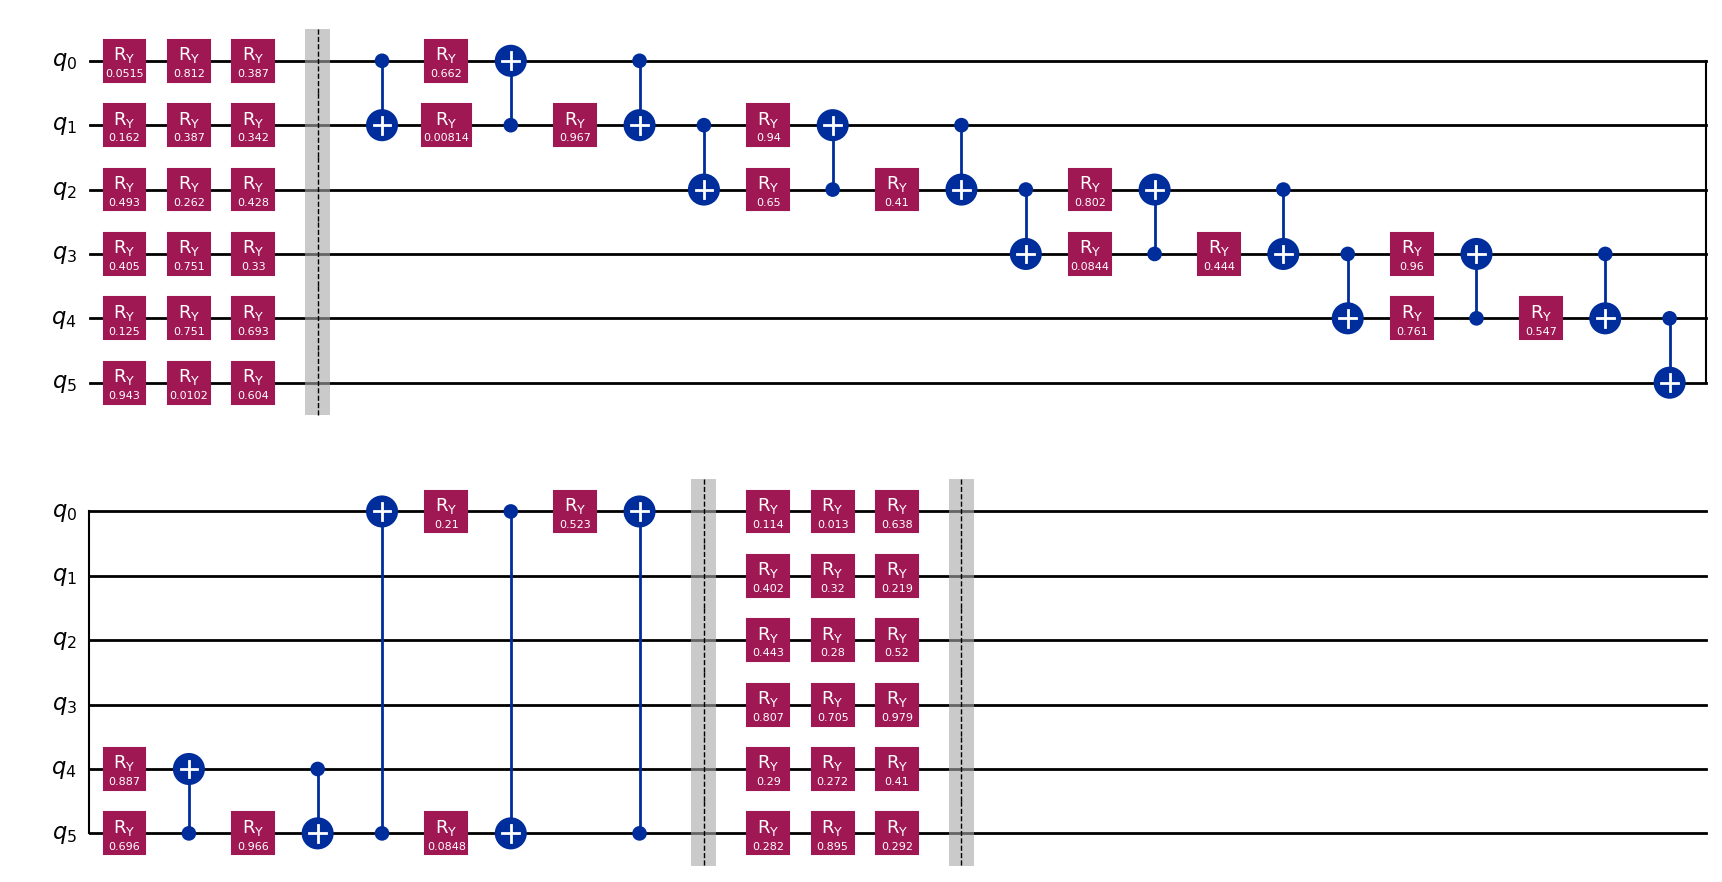

In [9]:
def ansatz(Parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=Parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc


depth=1
qubits=list(range(nb_qubits))
N=len(qubits)
nb_params=int(9*N*depth)
# Parameters = np.array([random.random() for _ in range(0, nb_params)])

Parameters = np.array(ray([0.05145285, 0.16212569, 0.49316096 0.4052961,  0.12518138, 0.94345683,
 0.81209812, 0.38701357, 0.26201778, 0.75143449, 0.75115973, 0.01015426,
 0.38699332, 0.34243863, 0.4277144 , 0.3302829 , 0.69296778, 0.60371413,
 0.6617106 , 0.93953061, 0.80236756, 0.9596587 , 0.88692455, 0.08482896,
 0.00813994, 0.64985383, 0.08441884, 0.76119411, 0.69573319, 0.21043226,
 0.96708973, 0.40972907, 0.4435394 , 0.54674529, 0.96556555, 0.52278073,
 0.11369606, 0.40161863, 0.44333345, 0.80650353, 0.29002813, 0.28213638,
 0.01296697, 0.32039161, 0.2795081 , 0.70526085, 0.2716424 , 0.89501745,
 0.63808767, 0.21899544, 0.52000262, 0.97949799, 0.40966426, 0.29172039]
)
print(Parameters)
ansatz(Parameters).draw("mpl")

In [11]:
def circ(Parameters):
    x=QuantumRegister(22)
    c=ClassicalRegister(16)
    circuit = QuantumCircuit(x,c)
    circuit=circuit.compose(ansatz(Parameters),x[16:22])
    circuit.h(x[0:16])

#Apply the C-U operations where the controlled qubits are the qubits of the register x and the target from y    
    circuit.append(C_u1gate, [x[0],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u2gate, [x[1],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u3gate, [x[2],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u4gate, [x[3],x[16],x[17],x[18],x[19],x[20],x[21]])  
    circuit.append(C_u5gate, [x[4],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u6gate, [x[5],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u7gate, [x[6],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u8gate, [x[7],x[16],x[17],x[18],x[19],x[20],x[21]]) 
    circuit.append(C_u9gate, [x[8],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u10gate, [x[9],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u11gate, [x[10],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u12gate, [x[11],x[16],x[17],x[18],x[19],x[20],x[21]]) 
    circuit.append(C_u13gate, [x[12],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u14gate, [x[13],x[16],x[17],x[18],x[19],x[20],x[21]]) 
    circuit.append(C_u15gate, [x[14],x[16],x[17],x[18],x[19],x[20],x[21]])    
    circuit.append(C_u16gate, [x[15],x[16],x[17],x[18],x[19],x[20],x[21]])    
#Apply the inverse QFT on the x register   
    circuit &= QFT(num_qubits = 16, approximation_degree = 0, do_swaps=True, 
                   inverse = True, insert_barriers = False, name ='qftinv')
    circuit.measure(x[0:16],c)       
    return circuit

In [12]:
1/2**16

1.52587890625e-05

/tmp/ipykernel_2114224/623116687.py:28: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 16, approximation_degree = 0, do_swaps=True,


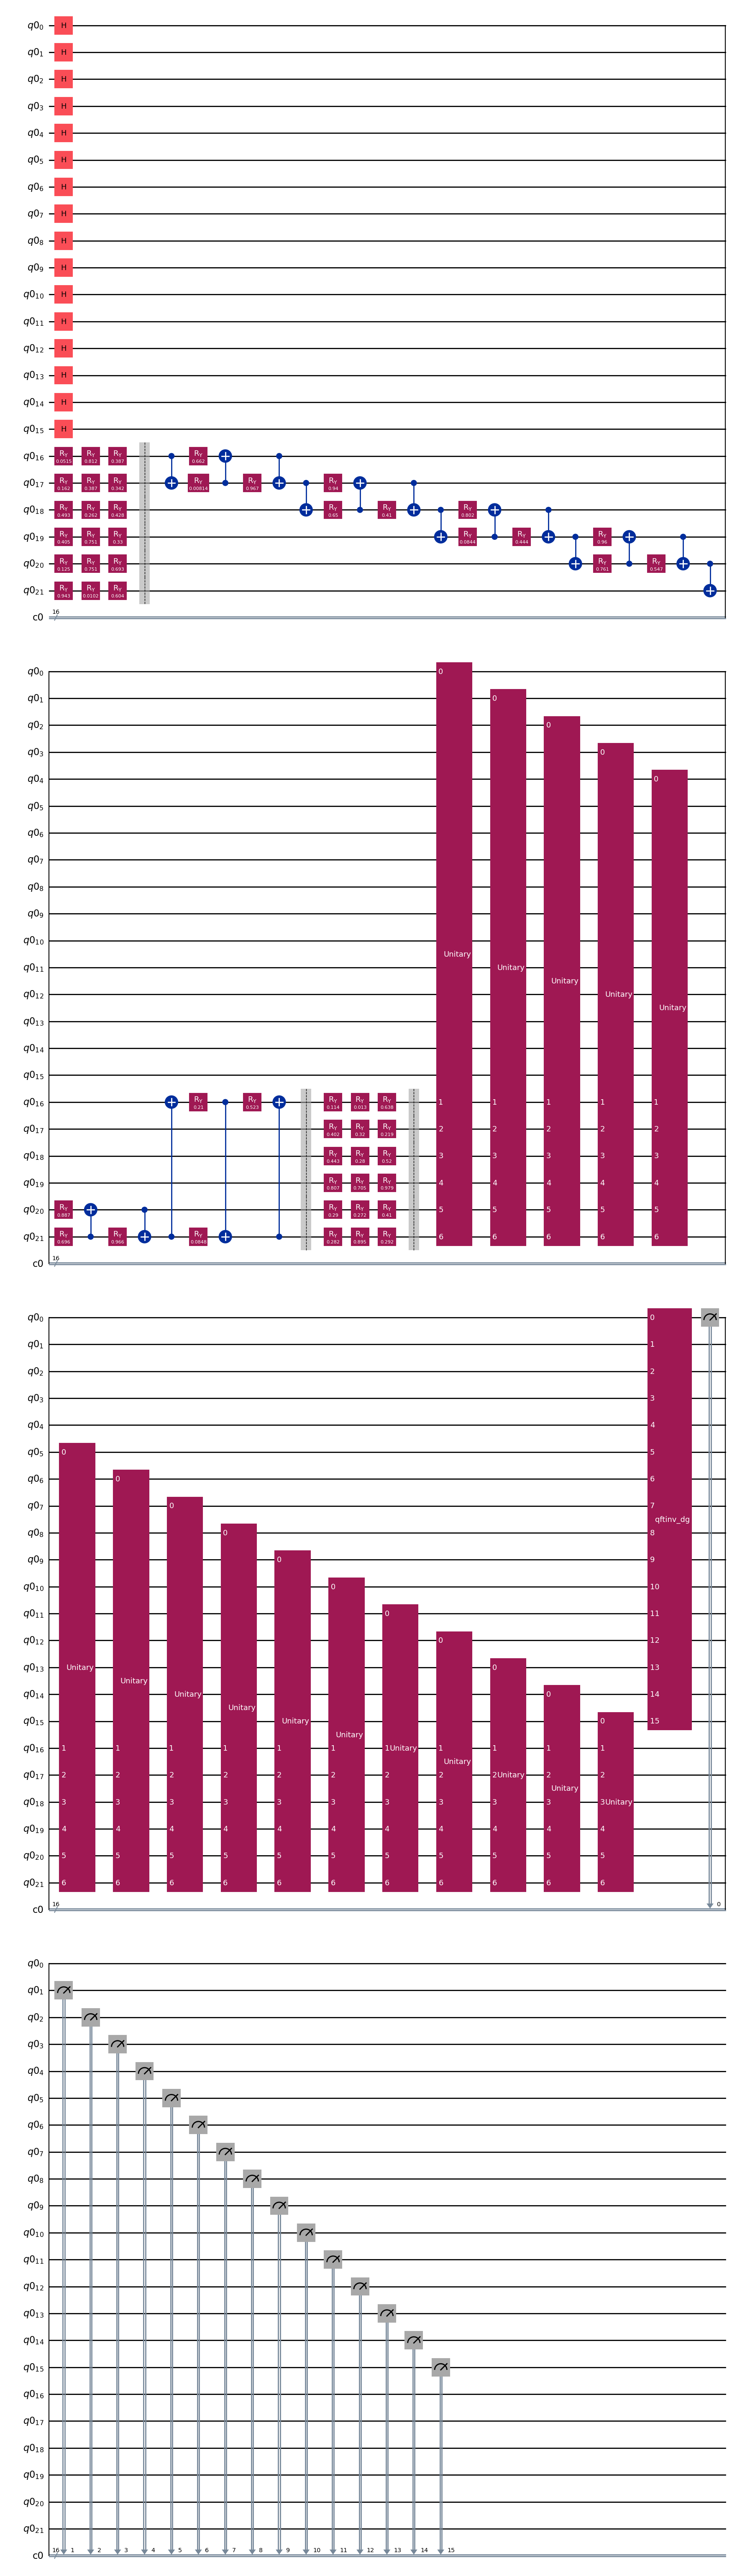

In [13]:
circ(Parameters).draw("mpl") 

In [14]:
shots = 500000
def cost(Parameters):
    job = backend.run(pm.run(circ(Parameters)),shots = shots).result()
    result = job.get_counts(0)
    if '0000000000000000'not in result: 
        res = 1
    else:
        res = 1 - result['0000000000000000']/shots
    return res
# cost(Parameters)


In [15]:
import warnings
warnings.filterwarnings("ignore")
from qiskit_algorithms.optimizers import SPSA
learning_rate = 0.1
def save(nfev, Parameters, cost, learning_rate, trust_region):
    global Cost,Params
    Cost.append(cost)
    Params.append(Parameters)
    print(nfev, cost)
Cost = []
Params = []
spsa = SPSA(maxiter = 3000, callback =save)
spsa.minimize(cost, Parameters)
# print(Cost)
    

3 0.996958
6 0.994626
9 0.986246
12 0.99572
15 0.992054
18 0.993676
21 0.992816
24 0.991166
27 0.962314
30 0.999276
33 0.96707
36 0.968866
39 0.969222
42 0.972966
45 0.998032
48 0.99798
51 0.981642
54 0.981702
57 0.979402
60 0.9487
63 0.95085
66 0.99912
69 0.99966
72 0.999882
75 0.999908
78 0.999828
81 0.999812
84 0.999894
87 0.999836
90 0.999964
93 0.999936
96 0.999942
99 0.999236
102 0.990062
105 0.9509879999999999
108 0.962494
111 0.910254
114 0.932772
117 0.7182200000000001
120 0.744818
123 0.973962
126 0.999934
129 0.99996
132 0.999944
135 0.999964
138 0.999956
141 0.999962
144 0.999944
147 0.999962
150 0.999944
153 0.99995
156 0.999932
159 0.999908
162 0.999914
165 0.999934
168 0.999898
171 0.99993
174 0.99989
177 0.999926
180 0.998494
183 0.994682
186 0.994716
189 0.982508
192 0.821982
195 0.969834
198 0.964756
201 0.964126
204 0.960232
207 0.95734
210 0.960736
213 0.951118
216 0.969488
219 0.964198
222 0.9201280000000001
225 0.994002
228 0.988574
231 0.986732
234 0.986864
237 0

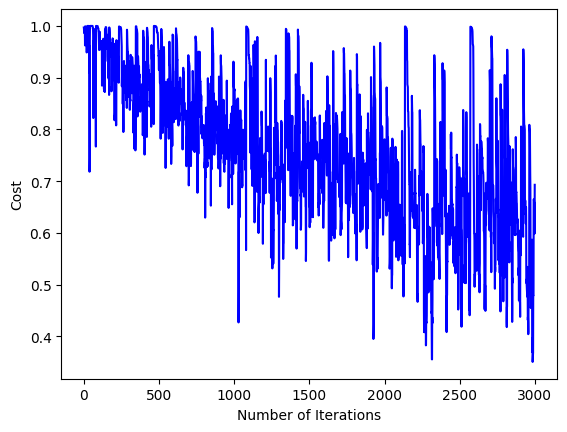

In [16]:
plt.plot(range(len(Cost)), Cost,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.show()


In [17]:
x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)

In [18]:
e = []
F = []
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    psi = np.dot(m,state)
    Psi = psi/np.linalg.norm(psi)
    norm = np.dot(Psi,b)
    e.append(x_exact - state/norm)
    # f = abs(np.dot(Psi,b))**2
    f = abs(np.dot(state,x_exact))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))

Text(0.5, 0, 'Iteration')

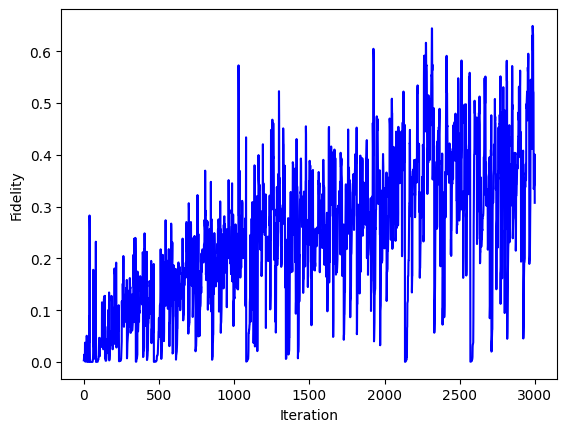

In [19]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(F)),F,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Fidelity')
plt.xlabel('Iteration')


In [20]:
norm_e[np.argmax(F)]

5.108854085133634

In [21]:
ef = abs(np.array(e[np.argmax(F)]))
ef

array([0.2084541 , 0.62082883, 0.37065045, 0.7503526 , 0.24500912,
       0.22191896, 0.71882512, 0.5020226 , 0.35992498, 0.46394498,
       0.44412269, 0.58362979, 0.25010163, 0.20733866, 0.6060913 ,
       0.38784297, 0.78062929, 0.57419487, 0.88805153, 0.66792798,
       0.27612031, 0.16515331, 1.24057423, 0.57777261, 0.6164103 ,
       0.45206209, 0.76206356, 0.55312945, 0.2670648 , 0.17359572,
       0.30250764, 0.24111629, 0.78813487, 1.38359334, 0.96485808,
       1.68754348, 0.3809555 , 0.75598277, 0.014439  , 1.01432401,
       0.77812915, 1.33227344, 0.912911  , 1.60964805, 0.35034757,
       0.65353881, 0.595573  , 1.03852086, 0.10844086, 0.20632658,
       0.09677766, 0.28975496, 0.10533708, 0.11164828, 0.45718251,
       0.48652459, 0.03642125, 0.24576725, 0.04283241, 0.33981166,
       0.02143066, 0.13901721, 0.00564504, 0.22617706])

Text(0.5, 0, 'Iteration')

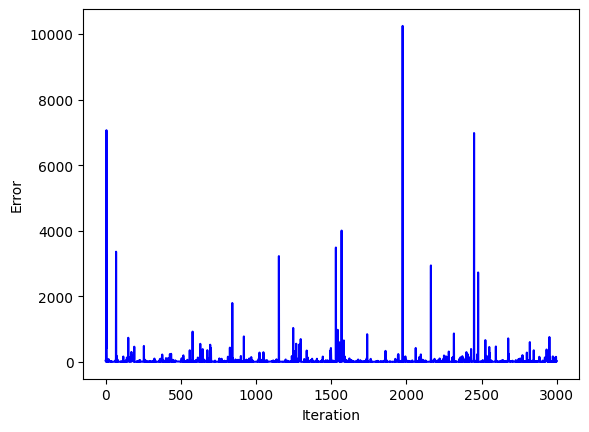

In [22]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(norm_e)),norm_e,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Error')
plt.xlabel('Iteration')

In [23]:
X_opt  = np.array(Statevector(ansatz(Params[-1])))
psi = m@X_opt
psi = psi/np.linalg.norm(psi)

In [24]:
abs(np.array(e[-1]))

array([ 0.03417225,  1.84279846,  0.15159668,  1.93796794,  0.90420027,
        1.52174467,  0.50039805,  1.24147736,  1.04391896,  4.85092606,
        0.65170616,  0.48290843,  0.6058763 ,  8.12311596,  0.0687292 ,
        3.43834976,  0.02596025,  0.86876794,  0.14648209,  0.74809572,
        0.04211408,  0.45976415,  0.0259723 ,  0.67590302,  0.3367928 ,
        2.24994234,  0.03407516,  0.32948632,  0.59550119,  4.13459458,
        0.01943305,  1.3583641 ,  2.0444143 ,  0.89573396,  0.96405781,
        1.43408284,  2.92789573,  2.89806903,  0.08633119,  2.61804371,
        7.33005552,  5.39556532,  3.53250056,  3.69815181, 10.62776733,
        6.38672885,  0.97250698,  0.77944954,  0.96530393,  0.19349868,
        1.76385204,  0.1390444 ,  0.38063575,  0.06620558,  1.81313728,
        0.23947893,  2.30569358,  0.50585689,  0.19480294,  0.04995764,
        4.42439305,  1.23401454,  2.17722802,  0.61342855])

In [25]:
X_opt

array([ 1.52596588e-03+0.j,  8.27487472e-02+0.j,  7.60387709e-03+0.j,
        8.77504597e-02+0.j, -3.87909585e-02+0.j,  6.99158657e-02+0.j,
       -2.00072131e-02+0.j, -5.27242471e-02+0.j, -4.35262985e-02+0.j,
        2.20084687e-01+0.j, -2.52600800e-02+0.j,  2.57822281e-02+0.j,
       -2.24616342e-02+0.j,  3.67708546e-01+0.j,  8.41486496e-03+0.j,
        1.59261641e-01+0.j,  7.09211817e-03+0.j,  4.49389519e-02+0.j,
       -2.68412041e-04+0.j,  3.98078215e-02+0.j,  8.41087566e-03+0.j,
        2.71898424e-02+0.j,  5.62797249e-03+0.j, -2.32660125e-02+0.j,
        2.20847953e-02+0.j,  1.07645475e-01+0.j,  8.82440449e-03+0.j,
        2.21447776e-02+0.j,  3.41524557e-02+0.j,  1.92319859e-01+0.j,
        8.68556442e-03+0.j,  6.86044470e-02+0.j,  9.92040528e-02+0.j,
        4.78735405e-02+0.j,  5.08060990e-02+0.j, -5.64016186e-02+0.j,
        1.38264621e-01+0.j,  1.36814255e-01+0.j,  1.11373039e-02+0.j,
        1.24072788e-01+0.j,  3.34369805e-01+0.j,  2.47866455e-01+0.j,
        1.64552618e-

In [26]:
print(F)

[0.003006474953333562, 0.005399861497918536, 0.01399782014494875, 0.004110298997783114, 0.008022951072262136, 0.006297727862203845, 0.007276037725541663, 0.008891229076342955, 0.03718594212681925, 0.0007465132510436835, 0.03332665527298786, 0.030877299361704462, 0.030751112932494804, 0.02723344246257136, 0.0011562883365578698, 0.0011627867222852777, 0.01821167631135434, 0.017852066160181018, 0.01990726315441771, 0.050526541441980134, 0.049103680277446396, 0.0008556733024642668, 0.00033941079924103084, 7.790926937006732e-05, 7.928671369188303e-05, 0.00014865118964199685, 0.00014910618675351278, 0.00011892071348076352, 0.00016957604521419277, 3.7984065885667894e-05, 4.133241812831065e-05, 4.132465758592767e-05, 0.0007377070903276736, 0.009751637556941651, 0.04857150418976443, 0.037216679322186974, 0.08868364007445971, 0.06695675419948259, 0.28274338215041445, 0.2557392851847594, 0.02619524295426353, 1.3054317923171666e-05, 1.1320455728255795e-05, 1.8478138068714493e-06, 1.921393883410185

In [27]:
print(norm_e)

[39.29082411596733, 14.238148014943608, 5.561280389543202, 3254.1711181234914, 414.3470572584823, 7066.231154835325, 559.342491812433, 25.18003702401236, 16.927164090960474, 17.360138524113097, 11.089460895778364, 18.182706544386953, 17.826274175197888, 10.54598476632764, 4.425838249332532, 4.423773763365021, 5.7393866299868765, 8.381801949904046, 9.354322845530984, 87.38911477467131, 46.000619947026316, 8.208263955605707, 9.096199831176957, 9.118330672363706, 9.097251540000194, 11.535459589887736, 11.799115317188255, 11.720299355702855, 11.04491990400353, 10.073651236853161, 10.141770060877574, 10.14214292985487, 10.432234627890422, 11.905588379834379, 27.76192126716332, 16.54774181384056, 6.339855118002669, 12.74343650355508, 10.84386914722119, 16.920086923499575, 5.386564412602302, 5.823734025772528, 5.846065514156083, 5.658348640287033, 5.784466737870468, 5.50553375137599, 5.781717158760354, 5.813992484168752, 5.855581296950557, 5.89730396685245, 5.950206745274903, 6.04711878690301

In [28]:
min(norm_e)

1.5243514497726707

In [29]:
1-max(F)

0.3511874572098975